In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importación de librerías principales para análisis y visualización de datos

In [3]:
import os
import snowflake.connector
import pandas as pd

conn = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema=os.getenv("SNOWFLAKE_SCHEMA_ANALYTICS"),
    role=os.getenv("SNOWFLAKE_ROLE"),
)

query = """
SELECT *
FROM OBT_TRIPS
LIMIT 100000
"""

df = pd.read_sql(query, conn)

df.head()

/tmp/ipykernel_418/3296212413.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,PICKUP_DATETIME,DROPOFF_DATETIME,PICKUP_DATE,PICKUP_HOUR,DROPOFF_DATE,DROPOFF_HOUR,DAY_OF_WEEK,MONTH,YEAR,PU_LOCATION_ID,...,AIRPORT_FEE,EHAIL_FEE,TOTAL_AMOUNT,TRIP_DURATION_MIN,AVG_SPEED_MPH,TIP_PCT,RUN_ID,INGESTED_AT_UTC,SOURCE_YEAR,SOURCE_MONTH
0,2015-01-01 07:49:06,2015-01-01 07:52:44,2015-01-01,7,2015-01-01,7,4,1,2015,263,...,None,None,6.80,3.63,11.56,20.00,run_local_001,2026-04-02 05:46:00.384194,2015,1
1,2015-01-01 07:32:17,2015-01-01 07:35:32,2015-01-01,7,2015-01-01,7,4,1,2015,50,...,None,None,5.80,3.25,14.77,0.00,run_local_001,2026-04-02 05:46:00.384194,2015,1
2,2015-01-01 07:12:26,2015-01-01 07:21:48,2015-01-01,7,2015-01-01,7,4,1,2015,56,...,None,None,16.30,9.37,32.67,0.00,run_local_001,2026-04-02 05:46:00.384194,2015,1
3,2015-01-01 07:26:45,2015-01-01 07:37:19,2015-01-01,7,2015-01-01,7,4,1,2015,237,...,None,None,14.05,10.57,18.17,15.22,run_local_001,2026-04-02 05:46:00.384194,2015,1
4,2015-01-01 07:23:23,2015-01-01 07:29:30,2015-01-01,7,2015-01-01,7,4,1,2015,244,...,None,None,7.30,6.12,11.77,0.00,run_local_001,2026-04-02 05:46:00.384194,2015,1


## Inspección general del DataFrame: tipos de datos, uso de memoria y valores no nulos

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   PICKUP_DATETIME        100000 non-null  datetime64[ns]
 1   DROPOFF_DATETIME       100000 non-null  datetime64[ns]
 2   PICKUP_DATE            100000 non-null  object        
 3   PICKUP_HOUR            100000 non-null  int64         
 4   DROPOFF_DATE           100000 non-null  object        
 5   DROPOFF_HOUR           100000 non-null  int64         
 6   DAY_OF_WEEK            100000 non-null  int64         
 7   MONTH                  100000 non-null  int64         
 8   YEAR                   100000 non-null  int64         
 9   PU_LOCATION_ID         100000 non-null  int64         
 10  PU_ZONE                100000 non-null  object        
 11  PU_BOROUGH             100000 non-null  object        
 12  DO_LOCATION_ID         100000 non-null  int64

,PICKUP_HOUR,DROPOFF_HOUR,DAY_OF_WEEK,MONTH,YEAR,PU_LOCATION_ID,DO_LOCATION_ID,VENDOR_ID,RATE_CODE_ID,PAYMENT_TYPE,...,MTA_TAX,TIP_AMOUNT,TOLLS_AMOUNT,IMPROVEMENT_SURCHARGE,TOTAL_AMOUNT,TRIP_DURATION_MIN,AVG_SPEED_MPH,TIP_PCT,SOURCE_YEAR,SOURCE_MONTH
count,100000.000000,100000.00000,100000.000000,100000.0,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,99994.000000,99988.000000,100000.0,100000.0
mean,13.300970,13.27106,4.844630,1.0,2015.0,160.006410,157.598110,1.537050,1.037020,1.495630,...,0.498235,1.245940,0.276460,0.159591,14.707077,13.080624,14.718900,10.457056,2015.0,1.0
std,6.439674,6.50728,0.697277,0.0,0.0,67.881772,71.607707,0.498628,0.501171,0.509042,...,0.029655,2.099938,1.365124,0.149694,12.526872,92.937743,7.386637,13.370644,0.0,0.0
min,0.000000,0.00000,4.000000,1.0,2015.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.300000,0.000000,0.000000,0.000000,2015.0,1.0
25%,9.000000,9.00000,4.000000,1.0,2015.0,113.000000,106.000000,1.000000,1.000000,1.000000,...,0.500000,0.000000,0.000000,0.000000,7.800000,5.700000,10.030000,0.000000,2015.0,1.0
50%,14.000000,14.00000,5.000000,1.0,2015.0,161.000000,161.000000,2.000000,1.000000,1.000000,...,0.500000,0.000000,0.000000,0.300000,10.800000,9.220000,13.020000,0.000000,2015.0,1.0
75%,19.000000,19.00000,5.000000,1.0,2015.0,231.000000,231.000000,2.000000,1.000000,2.000000,...,0.500000,1.900000,0.000000,0.300000,15.800000,14.480000,17.250000,21.180000,2015.0,1.0
max,23.000000,23.00000,6.000000,1.0,2015.0,265.000000,265.000000,2.000000,99.000000,4.000000,...,0.500000,81.000000,77.550000,0.300000,325.960000,25367.280000,146.670000,952.940000,2015.0,1.0


## Validaciones

Chequeo de calidad de datos: conteo de valores nulos o faltantes en cada columna

In [5]:
# Validación Global: Contar todos los registros nulos en todas las columnas de la tabla OBT (sin límite de 100k)
# Construimos una query dinámica para contar los nulos de cada columna.
def check_all_nulls_snowflake(conn, database, schema, table):
    cur = conn.cursor()
    # Obtener el nombre de las columnas
    cur.execute(f"SELECT COLUMN_NAME FROM {database}.INFORMATION_SCHEMA.COLUMNS WHERE TABLE_SCHEMA = '{schema}' AND TABLE_NAME = '{table}'")
    columns = [row[0] for row in cur.fetchall()]
    
    # Construir sentencia SELECT SUM(CASE WHEN col IS NULL THEN 1 ELSE 0 END)
    select_exprs = [f"SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS {col}_NULLS" for col in columns]
    query = f"SELECT {', '.join(select_exprs)} FROM {schema}.{table}"
    
    print("Ejecutando validación de nulos en OBT (puede tomar unos segundos)...")
    df_nulls = pd.read_sql(query, conn)
    
    # Transponer para mejor visualización
    df_nulls_t = df_nulls.T
    df_nulls_t.columns = ['null_count']
    df_nulls_t = df_nulls_t.sort_values(by='null_count', ascending=False)
    return df_nulls_t

# Ejecutar (asegúrate de que conn y ANALYTICS_SCHEMA estén instanciados, usar OBT_TRIPS)
df_global_nulls = check_all_nulls_snowflake(conn, os.getenv("SNOWFLAKE_DATABASE"), os.getenv("SNOWFLAKE_SCHEMA_ANALYTICS"), "OBT_TRIPS")
df_global_nulls[df_global_nulls['null_count'] > 0]


Ejecutando validación de nulos en OBT (puede tomar unos segundos)...


/tmp/ipykernel_418/3874233063.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_nulls = pd.read_sql(query, conn)


,null_count
EHAIL_FEE_NULLS,855251007
TRIP_TYPE_NULLS,790273397
AIRPORT_FEE_NULLS,684875849
CONGESTION_SURCHARGE_NULLS,569775492
STORE_AND_FWD_FLAG_NULLS,19353325
AVG_SPEED_MPH_NULLS,565112
TIP_PCT_NULLS,255151
IMPROVEMENT_SURCHARGE_NULLS,4


In [6]:
df.isnull().sum().sort_values(ascending=False)

AIRPORT_FEE              100000
EHAIL_FEE                100000
TRIP_TYPE                100000
CONGESTION_SURCHARGE     100000
TIP_PCT                      12
AVG_SPEED_MPH                 6
TOLLS_AMOUNT                  0
TRIP_DISTANCE                 0
STORE_AND_FWD_FLAG            0
FARE_AMOUNT                   0
EXTRA                         0
MTA_TAX                       0
TIP_AMOUNT                    0
PICKUP_DATETIME               0
IMPROVEMENT_SURCHARGE         0
TOTAL_AMOUNT                  0
TRIP_DURATION_MIN             0
RUN_ID                        0
INGESTED_AT_UTC               0
SOURCE_YEAR                   0
PASSENGER_COUNT               0
PAYMENT_TYPE_DESC             0
DROPOFF_DATETIME              0
PU_ZONE                       0
PICKUP_DATE                   0
PICKUP_HOUR                   0
DROPOFF_DATE                  0
DROPOFF_HOUR                  0
DAY_OF_WEEK                   0
MONTH                         0
YEAR                          0
PU_LOCAT

Chequeo de duplicados absolutos en el conjunto extraído

In [7]:
df.duplicated().sum()

0

Listado de columnas retornadas desde el motor de base de datos

In [8]:
df.columns.tolist()

['PICKUP_DATETIME',
 'DROPOFF_DATETIME',
 'PICKUP_DATE',
 'PICKUP_HOUR',
 'DROPOFF_DATE',
 'DROPOFF_HOUR',
 'DAY_OF_WEEK',
 'MONTH',
 'YEAR',
 'PU_LOCATION_ID',
 'PU_ZONE',
 'PU_BOROUGH',
 'DO_LOCATION_ID',
 'DO_ZONE',
 'DO_BOROUGH',
 'SERVICE_TYPE',
 'VENDOR_ID',
 'VENDOR_NAME',
 'RATE_CODE_ID',
 'RATE_CODE_DESC',
 'PAYMENT_TYPE',
 'PAYMENT_TYPE_DESC',
 'TRIP_TYPE',
 'PASSENGER_COUNT',
 'TRIP_DISTANCE',
 'STORE_AND_FWD_FLAG',
 'FARE_AMOUNT',
 'EXTRA',
 'MTA_TAX',
 'TIP_AMOUNT',
 'TOLLS_AMOUNT',
 'IMPROVEMENT_SURCHARGE',
 'CONGESTION_SURCHARGE',
 'AIRPORT_FEE',
 'EHAIL_FEE',
 'TOTAL_AMOUNT',
 'TRIP_DURATION_MIN',
 'AVG_SPEED_MPH',
 'TIP_PCT',
 'RUN_ID',
 'INGESTED_AT_UTC',
 'SOURCE_YEAR',
 'SOURCE_MONTH']

Listado de columnas retornadas desde el motor de base de datos

In [9]:
df.columns = df.columns.str.lower()
df.columns.tolist()

['pickup_datetime',
 'dropoff_datetime',
 'pickup_date',
 'pickup_hour',
 'dropoff_date',
 'dropoff_hour',
 'day_of_week',
 'month',
 'year',
 'pu_location_id',
 'pu_zone',
 'pu_borough',
 'do_location_id',
 'do_zone',
 'do_borough',
 'service_type',
 'vendor_id',
 'vendor_name',
 'rate_code_id',
 'rate_code_desc',
 'payment_type',
 'payment_type_desc',
 'trip_type',
 'passenger_count',
 'trip_distance',
 'store_and_fwd_flag',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'congestion_surcharge',
 'airport_fee',
 'ehail_fee',
 'total_amount',
 'trip_duration_min',
 'avg_speed_mph',
 'tip_pct',
 'run_id',
 'ingested_at_utc',
 'source_year',
 'source_month']

Validación estructural: búsqueda de viajes con distancia negativa (esperamos 0 registros gracias a OBT)

In [10]:
df[df["trip_distance"] < 0]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


Validación de negocio: búsqueda de cobros totales negativos (esperamos 0 registros)

In [11]:
df[df["total_amount"] < 0]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


Validación de negocio: búsqueda de tarifa base negativa (esperamos 0 registros)

In [12]:
df[df["fare_amount"] < 0]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


Validación temporal: viajes donde la duración fue calculada como negativa

In [13]:
df[df["trip_duration_min"] < 0]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


Validación matemática: velocidad promedio negativa (no tiene sentido físico)

In [14]:
df[df["avg_speed_mph"] < 0]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


Validación: Número de pasajeros extremadamente anómalo (outliers severos)

In [15]:
df[df['passenger_count'] > 10]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


Validación: Velocidades superiores a 150 mph asumiendo errores de registro o de GPS en zonas urbanas

In [16]:
df[df['avg_speed_mph'] > 150]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


Validación: Viajes donde no se encontró correspondencia para la zona de recogida (pu_location_id fallido o foráneo)

In [17]:
df[df['pu_zone'].isnull()]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


Validación: Registros cuyo pickup_datetime se sale del filtro definido de su origen (source_year y source_month)

In [18]:
df[(df['pickup_datetime'].dt.year != df['source_year']) | (df['pickup_datetime'].dt.month != df['source_month'])]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


Resumen estadístico enfocado en distancias, montos, tiempos y velocidad para entender rangos de los datos

In [19]:
df[[
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "trip_duration_min",
    "avg_speed_mph",
    "tip_pct"
]].describe()

,trip_distance,fare_amount,tip_amount,total_amount,trip_duration_min,avg_speed_mph,tip_pct
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,99994.000000,99988.000000
mean,3.068874,12.094153,1.245940,14.707077,13.080624,14.718900,10.457056
std,3.720037,10.511451,2.099938,12.526872,92.937743,7.386637,13.370644
min,0.010000,0.000000,0.000000,0.300000,0.000000,0.000000,0.000000
25%,1.080000,6.200000,0.000000,7.800000,5.700000,10.030000,0.000000
50%,1.800000,9.000000,0.000000,10.800000,9.220000,13.020000,0.000000
75%,3.300000,13.500000,1.900000,15.800000,14.480000,17.250000,21.180000
max,73.100000,279.700000,81.000000,325.960000,25367.280000,146.670000,952.940000


Validación de integridad temporal: registros donde la fecha/hora de llegada es anterior a la de partida

In [20]:
df[df["dropoff_datetime"] < df["pickup_datetime"]]

,pickup_datetime,dropoff_datetime,pickup_date,pickup_hour,dropoff_date,dropoff_hour,day_of_week,month,year,pu_location_id,...,airport_fee,ehail_fee,total_amount,trip_duration_min,avg_speed_mph,tip_pct,run_id,ingested_at_utc,source_year,source_month


Conteo de tipos de servicios de taxi en el batch analizado

In [21]:
df["service_type"].value_counts()

yellow    100000
Name: service_type, dtype: int64

Verificación del alineamiento temporal de la fuente. Asegura que los datos importados pertenezcan a las fechas esperadas

In [22]:
df.groupby(["source_year", "source_month", "service_type"]).size().reset_index(name="total_rows")

,source_year,source_month,service_type,total_rows
0,2015,1,yellow,100000


## Exploración

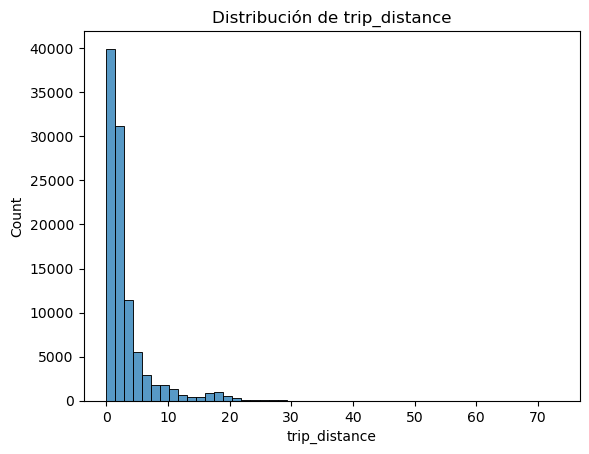

In [23]:
# Exploración visual: Distribución de la distancia de los viajes para identificar patrones generales (ej. viajes cortos vs largos)
sns.histplot(df["trip_distance"], bins=50)
plt.title("Distribución de trip_distance")
plt.show()

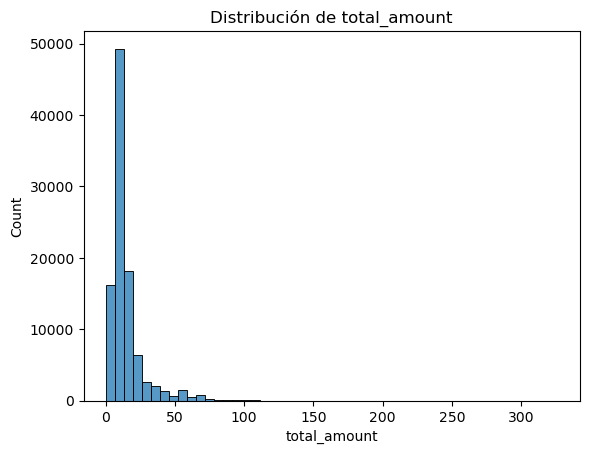

In [24]:
# Exploración visual: Distribución de los montos cobrados (ayuda a ver modas de pago)
sns.histplot(df["total_amount"], bins=50)
plt.title("Distribución de total_amount")
plt.show()

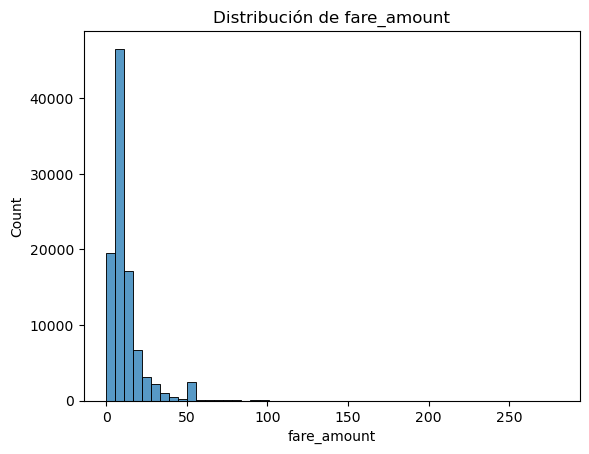

In [25]:
# Exploración visual: Distribución de la tarifa base
sns.histplot(df["fare_amount"], bins=50)
plt.title("Distribución de fare_amount")
plt.show()

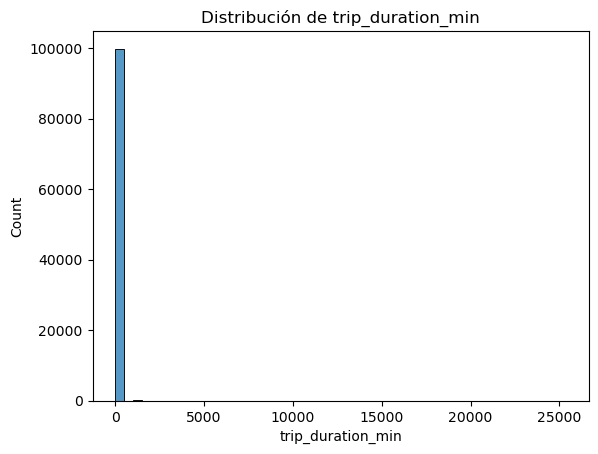

In [26]:
# Exploración visual: Distribución de la duración en minutos. Múltiples modas o colas largas indican congestión
sns.histplot(df["trip_duration_min"], bins=50)
plt.title("Distribución de trip_duration_min")
plt.show()

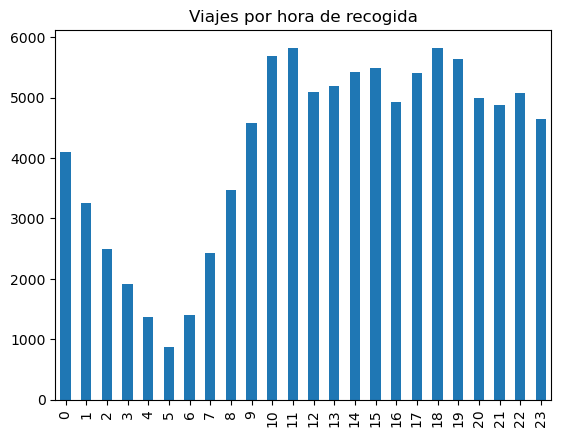

In [27]:
# Exploración visual: Volumen de viaje segmentado por hora del día. Útil para identificar horas punta (rush hours)
df["pickup_hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Viajes por hora de recogida")
plt.show()

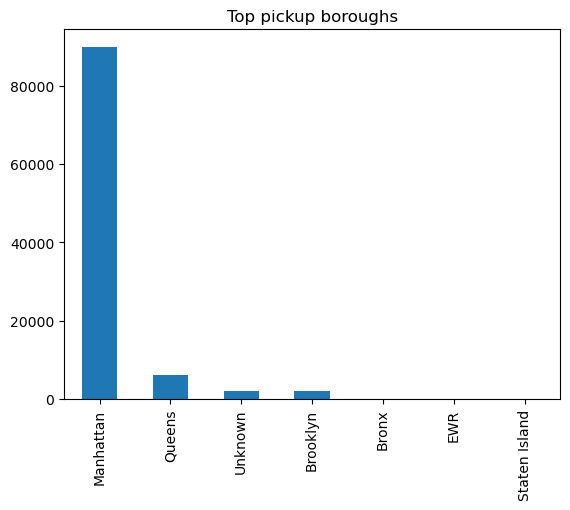

In [28]:
df["pu_borough"].value_counts().head(10).plot(kind="bar")
plt.title("Top pickup boroughs")
plt.show()

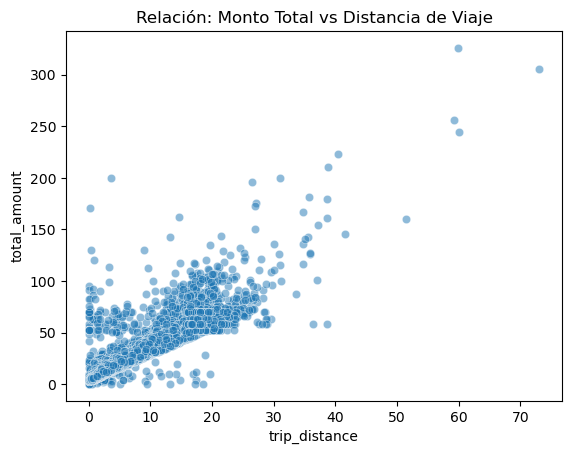

In [29]:
# Exploración visual: Dispersión entre el Monto Total de Pago y la Distancia del Viaje
sns.scatterplot(x='trip_distance', y='total_amount', data=df, alpha=0.5)
plt.title('Relación: Monto Total vs Distancia de Viaje')
plt.show()

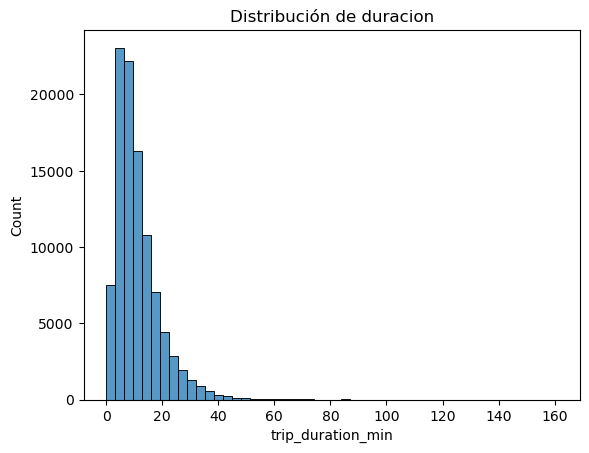

In [30]:
# Exploración visual: Histograma de duración de viajes
filtered_duration = df[df['trip_duration_min'] < 180]
sns.histplot(filtered_duration['trip_duration_min'], bins=50)
plt.title('Distribución de duracion')
plt.show()

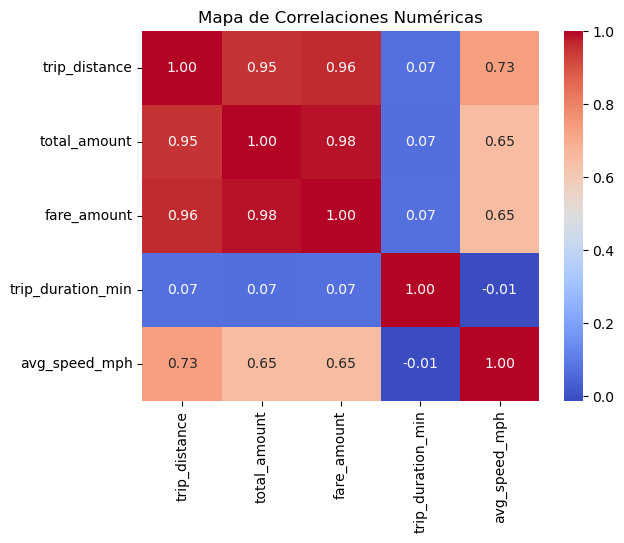

In [31]:
# Análisis de Correlación: Variables numéricas clave
corr_metrics = df[['trip_distance', 'total_amount', 'fare_amount', 'trip_duration_min', 'avg_speed_mph']].corr()
sns.heatmap(corr_metrics, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlaciones Numéricas')
plt.show()

Análisis: Promedio del cobro total segregado por tipo de servicio

In [32]:
df.groupby("service_type")["total_amount"].mean().sort_values(ascending=False)

service_type
yellow    14.707077
Name: total_amount, dtype: float64

Análisis: Distancia promedio recorrida por cada tipo de servicio

In [33]:
df.groupby("service_type")["trip_distance"].mean().sort_values(ascending=False)

service_type
yellow    3.068873
Name: trip_distance, dtype: float64

Resumen estadístico enfocado en distancias, montos, tiempos y velocidad para entender rangos de los datos

In [34]:
df.groupby("payment_type_desc")["tip_pct"].mean().sort_values(ascending=False)

payment_type_desc
Credit card    20.577829
Cash            0.000000
Dispute         0.000000
No charge       0.000000
Name: tip_pct, dtype: float64

Análisis de tráfico local: Velocidad promedio de viaje agrupada por el distrito de abordaje (Borough)

In [35]:
df.groupby("pu_borough")["avg_speed_mph"].mean().sort_values(ascending=False)

pu_borough
EWR              49.007500
Queens           27.368258
Staten Island    26.150000
Bronx            18.994706
Brooklyn         16.219078
Unknown          14.701163
Manhattan        13.822098
Name: avg_speed_mph, dtype: float64

## Validación adicional: Nulos en la Base de Datos completa
Revisamos los valores nulos en todas las columnas de la tabla `OBT_TRIPS` directamente en Snowflake, no limitados a la muestra local.

In [36]:
# Consultamos a Snowflake para contar nulos en toda la tabla usando COUNT_IF
print("Consultando valores nulos totales en OBT_TRIPS...")
null_selects = [f"COUNT_IF({col} IS NULL) AS {col}_NULLS" for col in df.columns]
null_query = f"SELECT {', '.join(null_selects)} FROM OBT_TRIPS"
df_full_nulls = pd.read_sql(null_query, conn)

# Mostramos resultados transpuestos para mejor legibilidad
display(df_full_nulls.T.rename(columns={0: 'Total Nulls'}).sort_values(by='Total Nulls', ascending=False))

Consultando valores nulos totales en OBT_TRIPS...


/tmp/ipykernel_418/112877404.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_full_nulls = pd.read_sql(null_query, conn)


,Total Nulls
EHAIL_FEE_NULLS,855251007
TRIP_TYPE_NULLS,790273397
AIRPORT_FEE_NULLS,684875849
CONGESTION_SURCHARGE_NULLS,569775492
STORE_AND_FWD_FLAG_NULLS,19353325
AVG_SPEED_MPH_NULLS,565112
TIP_PCT_NULLS,255151
IMPROVEMENT_SURCHARGE_NULLS,4
TIP_AMOUNT_NULLS,0
TRIP_DISTANCE_NULLS,0


In [37]:
# cierre de la conexión a la base de datos al finalizar
conn.close()
print("Snowflake connection closed")

Snowflake connection closed
